# 0. Analyse du biais

On établit d'abord **le constat** : le comité accorde-t-il moins de bourses aux régions éloignées, et cet
écart s'explique-t-il par le dossier des candidats ? On vérifie ensuite si le modèle de production
reproduit ce comportement. Les mesures d'équité formelles sont à la section 1, les variables proxys à la
section 2.

Analyses reprises de `analyse/analyse_donnees.ipynb` (§2 et §4) et de l'ancien audit
(`archives/audit_rapport_old.ipynb`, §2.1).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from analyse.analyse import (COULEURS_GROUPE, ENCRE_SECONDAIRE, GRILLE, chevauchement, entrainer_rf,
                             groupe_region, intervalle_bootstrap, matrice_correlation, metriques_equite,
                             repartition, stats_par_groupe, styliser, tableau_tranches, taux_octroi_par,
                             tracer_distributions, tracer_matrice, tracer_taux_par_quantile)
from cible import (NOUVELLES_VARIABLES, VARIABLES_MODELE, ajouter_attributs, ajuster_modele_decision,
                   appliquer_seuil, choisir_seuil, cible_individuelle, entrainer_modele_cible,
                   octroi_top_k, score_contrefactuel, score_merite)

pd.set_option('display.width', 200)

NUMERIQUES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
              'distance_domicile_campus_km']
BORNES_R = [0, 26, 27, 28, 29, 30, 32, 45]   # tranches de cote R, plus fines pres du seuil d'octroi

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')
demandes['groupe'] = groupe_region(demandes)   # Centre : Montreal, Capitale-Nationale ; Eloignee : les trois autres
candidats['groupe'] = groupe_region(candidats)
groupe = demandes['groupe'].to_numpy()

# Meme decoupage que la baseline et model_corrige.ipynb : 70/30, stratifie sur la decision du comite.
train, test = train_test_split(demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi'])
groupe_te = test['groupe'].to_numpy()

## A. Taux d'octroi du comité

Taux d'octroi historique (`decision_octroi`) par groupe, par région et par programme.

In [2]:
print(taux_octroi_par(demandes, 'groupe').round(3))
print()
print(taux_octroi_par(demandes, 'region_administrative').round(3))
print()
print(pd.crosstab(demandes['programme_etudes'], demandes['groupe'], values=demandes['decision_octroi'],
                  aggfunc='mean').assign(ecart=lambda t: t['Centre'] - t['Eloignee']).round(3))

          effectif  taux_octroi
groupe                         
Centre        6000        0.484
Eloignee      4000        0.273

                               effectif  taux_octroi
region_administrative                               
Bas-Saint-Laurent                  1293        0.269
Capitale-Nationale                 1999        0.484
Cote-Nord                          1178        0.263
Gaspesie-Iles-de-la-Madeleine      1529        0.284
Montreal                           4001        0.483

groupe             Centre  Eloignee  ecart
programme_etudes                          
Arts et lettres     0.457     0.261  0.196
Genie               0.499     0.291  0.208
Sante               0.486     0.264  0.222
Sciences            0.485     0.288  0.198
Sciences sociales   0.481     0.263  0.218


**Lecture.**
- Le comité accorde la bourse à **48.4 %** des candidats du Centre contre **27.3 %** des candidats éloignés :
  un écart de **21 points**.
- L'écart est **uniforme** : les trois régions éloignées sont entre 26 % et 28 %, les deux centres à 48 %, et
  l'écart vaut 20 à 22 points dans chacun des cinq programmes. Il ne vient donc ni d'une région ni d'un
  programme particulier : c'est la signature d'une pénalité liée à l'appartenance au groupe éloigné.

## B. À mérite scolaire égal

Un écart de taux d'octroi n'est pas en soi un biais : il pourrait refléter des dossiers plus faibles. On
compare donc la cote R des deux groupes, puis le taux d'octroi à cote R égale.

                            moyenne  ecart_type  mediane
cote_r_equivalent Centre      27.99        2.99    27.98
                  Eloignee    27.33        2.98    27.29

Taux d'octroi du comite par tranche de cote R :


groupe             Centre  Eloignee  ecart
cote_r_equivalent                         
(0, 26]             0.020     0.005  0.016
(26, 27]            0.161     0.038  0.123
(27, 28]            0.316     0.100  0.216
(28, 29]            0.593     0.256  0.336
(29, 30]            0.849     0.568  0.281
(30, 32]            0.958     0.831  0.128
(32, 45]            0.998     0.986  0.012


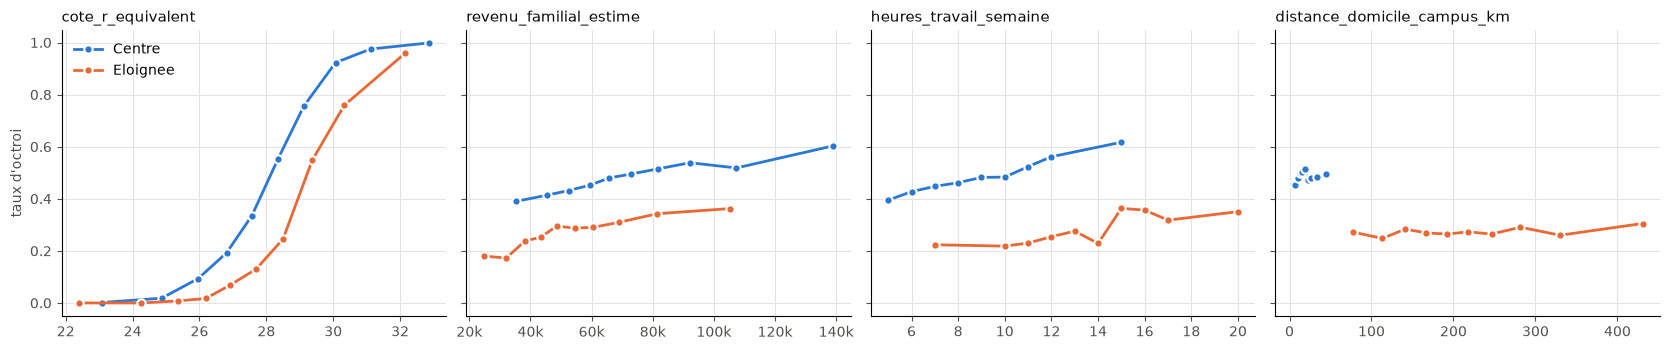

In [3]:
print(stats_par_groupe(demandes, ['cote_r_equivalent'])[['moyenne', 'ecart_type', 'mediane']].round(2))
print()
print('Taux d\'octroi du comite par tranche de cote R :')
tranche_r = pd.cut(demandes['cote_r_equivalent'], BORNES_R)
print(pd.crosstab(tranche_r, demandes['groupe'], values=demandes['decision_octroi'], aggfunc='mean')
      .assign(ecart=lambda t: t['Centre'] - t['Eloignee']).round(3))
tracer_taux_par_quantile(demandes, NUMERIQUES)

**Lecture.**
- La cote R est presque la même dans les deux groupes (28.0 contre 27.3, soit 0.2 écart-type) : le mérite scolaire n'explique pas un écart de 21 points.
- **À cote R égale**, l'écart est massif près du seuil d'octroi : entre 28 et 29, le comité accorde la bourse à 59 % des candidats du Centre contre 26 % des candidats éloignés ; entre 29 et 30, à 85 % contre 57 %. Loin du seuil (cote R de moins de 26 ou de 32 et plus), les deux groupes sont traités de la même façon : la pénalité touche les dossiers « limites ».
- Sur le premier graphique, la courbe des régions éloignées est décalée d'environ un point de cote R vers la droite : un candidat éloigné doit avoir une meilleure cote pour le même taux d'octroi.
- **Dans chaque groupe**, le taux d'octroi augmente aussi avec le revenu et avec les heures travaillées : le comité utilise d'autres critères que la cote R. Il faut donc en tenir compte (section C).

## C. Décomposition de l'écart

Pour tenir compte de tous les critères du comité à la fois, on le modélise par une régression logistique
qui inclut un indicateur de région (`cible.ajuster_modele_decision`, AUC de 0.95 contre `decision_octroi`).
On calcule ensuite, pour chaque candidat éloigné, sa probabilité d'octroi **s'il avait été traité comme un
candidat du Centre** : même dossier, indicateur de région mis à 0 (un *contrefactuel*). L'écart se décompose
en deux parts :
- **part due au profil** = taux du Centre - taux contrefactuel des éloignés. Elle vient des différences de
  dossier (cote R, revenu, heures...), valorisées comme le fait le comité ;
- **pénalité régionale** = taux contrefactuel des éloignés - leur taux observé. C'est la part qu'aucune
  caractéristique du dossier n'explique.

Les intervalles de confiance à 95 % sont obtenus par bootstrap stratifié par groupe (200 tirages) ; le modèle
est réajusté à chaque tirage.

In [4]:
def decomposer_ecart(indices):
    """Ecart d'octroi du comite (Centre - Eloignee), decompose en profil et penalite regionale."""
    s, g = demandes.iloc[indices], groupe[indices]
    modele = ajuster_modele_decision(s)
    centre = s.loc[g == 'Centre', 'decision_octroi'].mean()
    eloignee = s.loc[g == 'Eloignee', 'decision_octroi'].mean()
    # Taux d'octroi des candidats eloignes s'ils avaient ete traites comme ceux du Centre.
    eloignee_cf = score_contrefactuel(modele, s[g == 'Eloignee'], retrait=1).mean()
    return {'ecart_total': centre - eloignee,
            'part_profil': centre - eloignee_cf,
            'part_penalite_regionale': eloignee_cf - eloignee}


decomposition = intervalle_bootstrap(decomposer_ecart, np.arange(len(demandes)), strates=groupe, n=200)
print(decomposition.round(3))

                         estimation    bas   haut
ecart_total                   0.211  0.193  0.230
part_profil                   0.030  0.004  0.061
part_penalite_regionale       0.180  0.153  0.205


**Lecture.**
- Sur les **21 points** d'écart (IC 95 % : 19 à 23), **18 points** (IC : 15 à 21) restent inexpliqués à profil
  égal : c'est la **pénalité régionale directe**. Un candidat éloigné a 18 points de moins de chances
  d'obtenir la bourse qu'un candidat du Centre au dossier identique.
- Seuls **3 points** (IC : 0.4 à 6) s'expliquent par les différences de profil, surtout le revenu, plus élevé
  au Centre et valorisé par le comité.
- Limite : la distance des deux groupes ne se chevauche presque pas (seuls 21 % des dossiers éloignés sont
  dans l'étendue de distance du Centre, `analyse_donnees.ipynb` §2) ; le contrefactuel repose donc en partie
  sur l'extrapolation du modèle logistique.

## D. Le modèle de production reproduit le biais

Le modèle de production (forêt aléatoire de `baseline_model.ipynb`) est entraîné à reproduire
`decision_octroi`. On compare ses taux d'octroi à ceux du comité sur le jeu de test.

In [5]:
rf, X_te_rf, decisions_rf = entrainer_rf(train, test)
y_comite = test['decision_octroi'].to_numpy()

taux = pd.DataFrame({'comite': pd.Series(y_comite).groupby(groupe_te).mean(),
                     'RF de production': pd.Series(decisions_rf).groupby(groupe_te).mean()}).T
taux['ecart'] = taux['Centre'] - taux['Eloignee']
print(taux.round(3))
print(f'\nAccord du RF avec le comite : {(decisions_rf == y_comite).mean():.1%}')

                  Centre  Eloignee  ecart
comite             0.484     0.277  0.207
RF de production   0.459     0.271  0.188

Accord du RF avec le comite : 88.1%


**Lecture.** Le RF reproduit fidèlement le comité (88 % d'accord) : il accorde la bourse à 46 % des candidats
du Centre contre 27 % des candidats éloignés, un écart de 19 points, comparable aux 21 points du comité sur le
même jeu de test. Entraîné sur une étiquette biaisée, le modèle apprend la pénalité régionale avec le reste.
Toute évaluation qui le compare à `decision_octroi` ne peut donc pas détecter ce biais : c'est pourquoi la
section 1 mesure l'équité contre une référence de mérite.

# 1. Mesures d'équités

## A. Parité démographique
L'évaluation du la parité entre les 2 populations peut se faire par la comparaison des taux d'admission. 

Taux d'octroi par groupe et ecart de parite demographique (Centre - Eloignee)
                                                     Centre Eloignee global  ecart     IC 95 % ecart
jeu                 decision                                                                        
historique (10 000) comite                            0.484    0.273  0.399  0.211   [0.192 ; 0.229]
test (3 000)        comite                            0.484    0.277  0.399  0.207   [0.171 ; 0.241]
                    RF de production                  0.459    0.271  0.382  0.188   [0.155 ; 0.221]
                    nouveau modele                     0.43    0.417  0.425  0.013  [-0.024 ; 0.049]
candidats (4 000)   nouveau modele (predictions.csv)  0.438    0.421  0.432  0.017  [-0.018 ; 0.048]


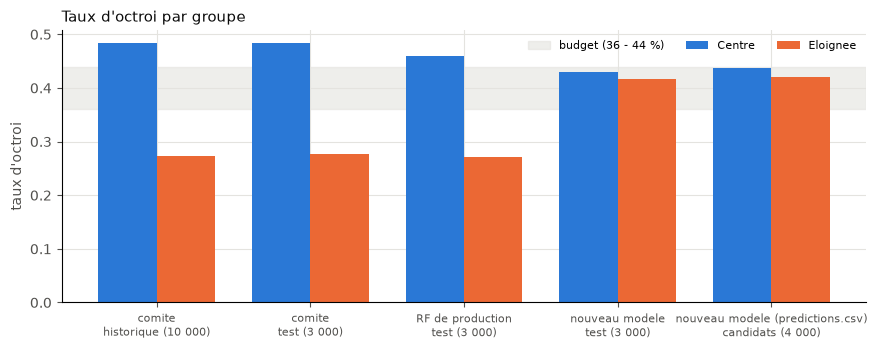

In [ ]:
# Nouveau modele : celui de model_corrige.ipynb (memes variables, meme cible, meme seuil), ajuste sur train.
avec_attributs = demandes.copy()
ajouter_attributs(avec_attributs, reference=demandes.copy())
VARIABLES_CORRIGE = VARIABLES_MODELE + NOUVELLES_VARIABLES
modele_decision = ajuster_modele_decision(train)   # modele du comite, ajuste sur train seulement
cible_train = cible_individuelle(modele_decision, train)
model_corrige = entrainer_modele_cible(avec_attributs.loc[train.index], cible_train, variables_supplementaires=NOUVELLES_VARIABLES)
seuil, _ = choisir_seuil(model_corrige.predict_proba(avec_attributs.loc[train.index, VARIABLES_CORRIGE])[:, 1],
                         cible_train, groupes=train['groupe'])
decisions_corrige = appliquer_seuil(
    model_corrige.predict_proba(avec_attributs.loc[test.index, VARIABLES_CORRIGE])[:, 1], seuil)

# Decisions soumises pour les 4 000 candidats (ecrites par model_corrige.ipynb).
predictions = pd.read_csv('predictions.csv')
assert (predictions['id_candidat'] == candidats['id_candidat']).all()


def parite(decisions, groupes):
    """Taux d'octroi par groupe, global, et ecart de parite demographique (Centre - Eloignee)."""
    d, g = np.asarray(decisions), np.asarray(groupes)
    return {'Centre': d[g == 'Centre'].mean(), 'Eloignee': d[g == 'Eloignee'].mean(), 'global': d.mean(),
            'ecart': d[g == 'Centre'].mean() - d[g == 'Eloignee'].mean()}


DECISIONS = {
    ('historique (10 000)', 'comite'): (demandes['decision_octroi'], groupe),
    ('test (3 000)', 'comite'): (y_comite, groupe_te),
    ('test (3 000)', 'RF de production'): (decisions_rf, groupe_te),
    ('test (3 000)', 'nouveau modele'): (decisions_corrige, groupe_te),
    ('candidats (4 000)', 'nouveau modele (predictions.csv)'): (predictions['decision_octroi'], candidats['groupe']),
}
lignes = {}
for cle, (d, g) in DECISIONS.items():
    t = intervalle_bootstrap(parite, d, g, strates=g)
    lignes[cle] = {**t['estimation'].round(3).to_dict(),
                   'IC 95 % ecart': f"[{t.loc['ecart', 'bas']:.3f} ; {t.loc['ecart', 'haut']:.3f}]"}
tableau_parite = pd.DataFrame(lignes).T.rename_axis(['jeu', 'decision'])
print('Taux d\'octroi par groupe et ecart de parite demographique (Centre - Eloignee)')
print(tableau_parite)

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(tableau_parite))
for k, (g, couleur) in enumerate(COULEURS_GROUPE.items()):
    ax.bar(x + (k - 0.5) * 0.38, tableau_parite[g].astype(float), width=0.38, color=couleur, label=g)
ax.axhspan(0.36, 0.44, color=GRILLE, alpha=0.6, zorder=0, label='budget (36 - 44 %)')
ax.set_xticks(x, [f'{d}\n{j}' for j, d in tableau_parite.index], fontsize=8)
ax.set_ylabel("taux d'octroi", color=ENCRE_SECONDAIRE)
styliser(ax, "Taux d'octroi par groupe")
ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper right')
plt.tight_layout()
plt.show()

**Lecture.**
- **Données historiques** : le comité accorde la bourse à 48 % des candidats du Centre contre 27 % des
  candidats éloignés, soit un écart de parité de **0.21** (IC 95 % : 0.19 à 0.23). Le RF de production le
  reproduit sur le jeu de test (0.19).
- **Nouveau modèle** : sur le même jeu de test, les taux deviennent 43 % et 42 % ; l'écart tombe à **0.013**,
  non significatif (IC : -0.02 à 0.05). Sur les 4 000 candidats (`predictions.csv`), 43.8 % contre 42.1 %,
  soit un écart de 0.02, lui aussi non significatif (IC : -0.02 à 0.05).
- La parité vient surtout de la **cible** : une fois la pénalité régionale retirée, les deux groupes ont
  presque le même mérite estimé (section 0.C : 3 points d'écart dus au profil). Le modèle n'utilise ni la
  région ni le code postal comme variables. Le seuil de décision, unique pour tous les candidats, est ensuite
  choisi dans le budget en donnant la priorité à la parité, puis à l'exactitude (`cible.choisir_seuil`).
- Le taux d'octroi global est de 43.1 % sur les candidats, dans le budget (36 - 44 %).
- La parité ne regarde que les décisions, pas le mérite : un tirage au sort la respecterait aussi. Elle ne
  suffit donc pas à juger l'équité ; la section 1.B mesure l'égalité des chances parmi les candidats
  qualifiés.

## B. Égalité des chances

Taux d'acceptation au sein des élèves qualifiés : parmi les candidats qui **méritent** la bourse, quelle part
l'obtient dans chaque groupe ? C'est le **taux de vrais positifs** (TPR). L'écart d'égalité des chances est la
différence de TPR, Centre moins Éloignée.

Cette mesure exige de savoir qui est qualifié. `decision_octroi` ne convient pas : c'est la décision biaisée
qu'on audite, et l'étalon de « mérite réel » du jury est caché. On utilise deux définitions, et on vérifie que
la conclusion ne dépend pas du choix :

| Qualification | Définition | Force | Faiblesse |
|---|---|---|---|
| **Cote R seule** | les 40 % meilleures cotes R | transparente, indépendante de toute modélisation | ignore les autres critères (heures travaillées, revenu) |
| **Mérite retenu** | décision du comité **sans sa pénalité régionale** (`cible.score_merite`), seuillée comme dans `modele_corrige.ipynb` | garde tous les critères du comité sauf la région | dérive du même modèle que la cible du nouveau modèle (circularité) |

In [7]:
# Qualification des dossiers du jeu de test, selon les deux definitions.
y_cote_r = octroi_top_k(test['cote_r_equivalent'], 0.40)
seuil_merite, _ = choisir_seuil(score_merite(modele_decision, train, reference=train), cible_train)
y_merite = appliquer_seuil(score_merite(modele_decision, test, reference=train), seuil_merite)
QUALIFICATIONS = {'cote R seule': y_cote_r, 'merite retenu': y_merite}
SYSTEMES = {'comite': y_comite, 'RF de production': decisions_rf, 'nouveau modele': decisions_corrige}

print('Part de candidats qualifies par groupe :')
print(pd.DataFrame({nom: pd.Series(y).groupby(groupe_te).mean() for nom, y in QUALIFICATIONS.items()}).T.round(3))
print()


def egalite_chances(y_qualifie, decisions, groupes):
    """TPR par groupe et ecart d'egalite des chances (Centre - Eloignee)."""
    y, d, g = np.asarray(y_qualifie), np.asarray(decisions), np.asarray(groupes)
    tpr = {grp: d[(g == grp) & (y == 1)].mean() for grp in ['Centre', 'Eloignee']}
    return {'TPR Centre': tpr['Centre'], 'TPR Eloignee': tpr['Eloignee'], 'ecart': tpr['Centre'] - tpr['Eloignee']}


lignes = {}
for nom_q, y in QUALIFICATIONS.items():
    for nom_s, d in SYSTEMES.items():
        t = intervalle_bootstrap(egalite_chances, y, d, groupe_te, strates=groupe_te)
        lignes[(nom_q, nom_s)] = {**t['estimation'].round(3).to_dict(),
                                  'IC 95 % ecart': f"[{t.loc['ecart', 'bas']:.3f} ; {t.loc['ecart', 'haut']:.3f}]"}
egalite = pd.DataFrame(lignes).T.rename_axis(['qualification', 'decision'])
print('Egalite des chances (jeu de test)')
print(egalite)
print()
print('Pour comparaison, ecart du RF mesure contre decision_octroi (methode de la baseline) :',
      round(egalite_chances(y_comite, decisions_rf, groupe_te)['ecart'], 3))

Part de candidats qualifies par groupe :
               Centre  Eloignee
cote R seule    0.429     0.358
merite retenu   0.454     0.419

Egalite des chances (jeu de test)
                               TPR Centre TPR Eloignee  ecart      IC 95 % ecart
qualification decision                                                          
cote R seule  comite                0.901        0.683  0.218    [0.168 ; 0.266]
              RF de production      0.995        0.756  0.238    [0.196 ; 0.280]
              nouveau modele        0.953        0.982 -0.029  [-0.049 ; -0.008]
merite retenu comite                0.897        0.626  0.271    [0.221 ; 0.318]
              RF de production      0.954        0.647  0.307    [0.265 ; 0.352]
              nouveau modele        0.927        0.949 -0.023   [-0.048 ; 0.002]

Pour comparaison, ecart du RF mesure contre decision_octroi (methode de la baseline) : 0.063


**Lecture.**
- **Qualification** : les deux définitions donnent un peu plus de qualifiés au Centre, mais l'écart est
  modeste : 7 points avec la cote R seule (43 % contre 36 %), 3.5 points avec le mérite retenu (45 % contre
  42 %), loin des 21 points d'écart d'octroi du comité.
- **Comité** : parmi les candidats qualifiés, le comité retient 90 % de ceux du Centre, mais seulement 68 %
  (cote R seule) ou 63 % (mérite retenu) de ceux des régions éloignées. L'écart d'égalité des chances est de
  **0.22 à 0.27**.
- **RF de production** : il reproduit et accentue légèrement cet écart (**0.24 à 0.31**). Le scoreur annonce
  0.270 contre l'étalon caché, entre nos deux estimations.
- **Nouveau modèle** : l'écart passe à **-0.03** (cote R seule) et **-0.02** (mérite retenu). Les candidats
  qualifiés des régions éloignées sont retenus à 95 à 98 %, légèrement plus que ceux du Centre (93 à 95 %) :
  une faible inversion, significative contre la cote R seule (IC sous zéro), pas contre le mérite retenu.
- Les deux définitions donnent le même classement et des écarts du même ordre : **la conclusion ne dépend pas
  de la définition de la qualification**. Contre le mérite retenu, le résultat du nouveau modèle est en partie
  circulaire ; la cote R seule sert de contrôle indépendant.

### Où se situe l'écart ?

TPR par tranche de cote R et par groupe, pour le RF de production et le nouveau modèle (qualification : cote R
seule ; les tranches de moins de 10 qualifiés sont omises).

--- RF de production ---
groupe    Centre  Eloignee
cote R                    
(28, 29]   0.969     0.071
(29, 30]   1.000     0.654
(30, 32]   1.000     0.994
(32, 45]   1.000     1.000

--- nouveau modele ---
groupe    Centre  Eloignee
cote R                    
(28, 29]   0.740     0.857
(29, 30]   0.985     1.000
(30, 32]   1.000     1.000
(32, 45]   1.000     1.000



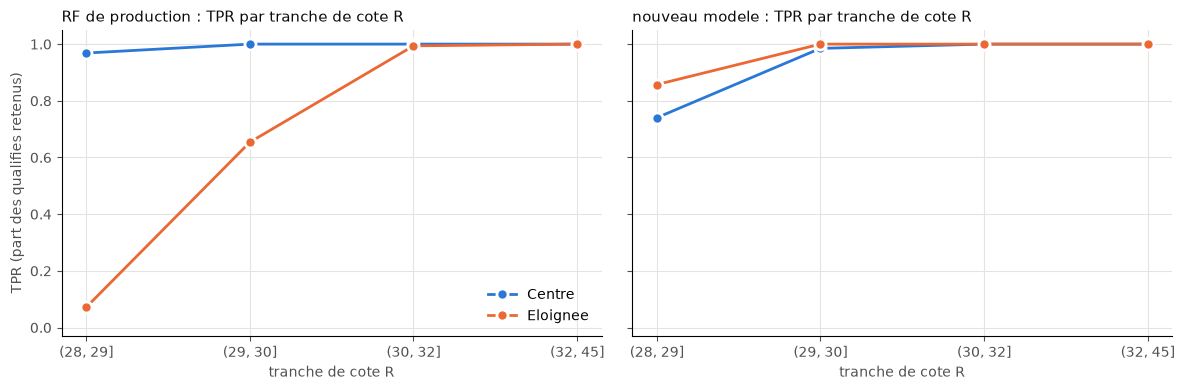

In [8]:
g_te = pd.Series(groupe_te, index=test.index, name='groupe')
tranche_r_te = pd.concat([pd.cut(test['cote_r_equivalent'], BORNES_R).astype(str).rename('cote R'), g_te], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, nom in zip(axes, ['RF de production', 'nouveau modele']):
    t = tableau_tranches(y_cote_r, SYSTEMES[nom], tranche_r_te)
    tpr = t['tpr'].where(t['meritants'] >= 10).unstack().dropna(how='all')
    x = np.arange(len(tpr))
    for g, couleur in COULEURS_GROUPE.items():
        ax.plot(x, tpr[g], '-o', color=couleur, lw=2, ms=8, mec='white', mew=2, label=g)
    ax.set_xticks(x, tpr.index)
    ax.set_xlabel('tranche de cote R', color=ENCRE_SECONDAIRE)
    ax.set_ylim(-0.03, 1.05)
    styliser(ax, f'{nom} : TPR par tranche de cote R')
    print(f'--- {nom} ---')
    print(tpr.round(3), end='\n\n')
axes[0].set_ylabel('TPR (part des qualifies retenus)', color=ENCRE_SECONDAIRE)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

**Lecture.** Le biais du RF se concentre juste au-dessus du seuil de qualification : entre 28 et 29 de cote R,
il retient 97 % des qualifiés du Centre contre **7 %** des qualifiés éloignés ; entre 29 et 30, 100 % contre
65 %. Au-delà de 30, les deux groupes sont traités de la même façon. Les candidats éloignés qui ne sont pas
« évidemment » admissibles sont presque tous refusés.

Le nouveau modèle referme l'écart au-delà de 29. Entre 28 et 29, il s'inverse : 86 % des qualifiés éloignés
sont retenus contre 74 % de ceux du Centre. C'est surtout de cette tranche que vient l'écart global de -0.03 : à la
frontière de qualification, le nouveau modèle favorise légèrement les candidats éloignés.

### Choix de la métrique : parité ou égalité des chances ?

Quand la part de qualifiés diffère entre les groupes, les deux critères ne peuvent pas être satisfaits
ensemble. On le vérifie avec deux décisions extrêmes, pour chaque définition :
- **décision parfaite** : la bourse va exactement aux qualifiés (égalité des chances parfaite) ;
- **parité imposée** : même taux d'octroi dans chaque groupe, attribué aux meilleurs scores du groupe.

In [9]:
SCORES = {'cote R seule': test['cote_r_equivalent'].to_numpy(),
          'merite retenu': score_merite(modele_decision, test, reference=train)}
lignes = {}
for nom, score in SCORES.items():
    y = QUALIFICATIONS[nom]
    decisions_parite = np.zeros(len(test), dtype=int)
    for g in ['Centre', 'Eloignee']:
        masque = groupe_te == g
        decisions_parite[masque] = octroi_top_k(score[masque], y.mean())
    lignes[(nom, 'decision parfaite')] = metriques_equite(y, y, groupe_te)
    lignes[(nom, 'parite imposee')] = metriques_equite(y, decisions_parite, groupe_te)
print(pd.DataFrame(lignes).T[['ecart_parite', 'ecart_egalite_chances', 'exactitude']].round(3))

                                 ecart_parite  ecart_egalite_chances  exactitude
cote R seule  decision parfaite         0.070                  0.000       1.000
              parite imposee            0.000                 -0.067       0.966
merite retenu decision parfaite         0.035                  0.000       1.000
              parite imposee           -0.001                 -0.032       0.983


**Lecture.**
- La **décision parfaite** a une égalité des chances exacte, mais garde un écart de parité de 7 points (cote R
  seule) ou de 3.5 points (mérite retenu) : l'écart de qualification entre les groupes.
- **Imposer la parité** crée un écart d'égalité des chances de -6.7 ou -3.2 points : des candidats éloignés
  moins qualifiés passent devant des candidats qualifiés du Centre.

**Choix : l'égalité des chances.**
1. **C'est une bourse au mérite** : la question équitable est de savoir si un candidat qualifié a la même chance
   d'être retenu, quelle que soit sa région. La parité imposerait un quota indépendant du mérite.
2. **Elle reste valable si la qualification diffère entre les groupes**, ce que la parité ne permet pas. Quand
   la qualification est presque égale, elle entraîne une parité presque exacte sans l'imposer (section 1.A).
3. **Le budget est fixe** : chaque bourse accordée à un candidat non qualifié en retire une à un candidat
   qualifié.
4. **Elle est lisible** pour un candidat refusé (« à mérite égal, votre région n'a pas compté »), et c'est la
   métrique du scoreur (20 points sur 35).

La parité reste suivie comme indicateur secondaire (section 1.A). L'égalité des chances se mesure toujours
contre une définition du mérite, **jamais contre `decision_octroi`** : contre l'étiquette du comité, le RF
paraît presque équitable (écart de 0.06, cellule ci-dessus), parce qu'on ne mesure alors que sa fidélité au
comité.

# 2. Variables proxy

Un **proxy** est une variable qui porte l'information de région. Un modèle peut s'en servir pour reproduire la
pénalité régionale sans jamais voir la colonne `region_administrative` : c'est pourquoi retirer la région ne
suffit pas (baseline, section 5 : l'écart de parité passe seulement de 0.188 à 0.173 sans la région ni le code
postal). Une variable est un proxy si sa distribution diffère nettement entre les deux groupes.

Analyses reprises de `analyse/analyse_donnees.ipynb` (§2, §3 et §5), sur les 10 000 dossiers historiques.

## A. Distribution des variables numériques par groupe

Statistiques par groupe, histogrammes superposés, puis **support commun** : la part de chaque groupe qui tombe
dans l'étendue [min, max] de l'autre. Un support commun faible signifie que la variable sépare les groupes.

                                       moyenne   mediane  ecart_type  asymetrie
cote_r_equivalent           Centre       27.99     27.98        2.99       0.03
                            Eloignee     27.33     27.29        2.98       0.00
revenu_familial_estime      Centre    76056.29  69175.50    33540.65       1.42
                            Eloignee  56330.32  51561.50    25563.62       1.29
heures_travail_semaine      Centre        8.97      9.00        2.98       0.32
                            Eloignee     13.02     13.00        3.61       0.30
distance_domicile_campus_km Centre       19.79     17.00       13.27       1.29
                            Eloignee    221.45    204.50      109.51       0.98


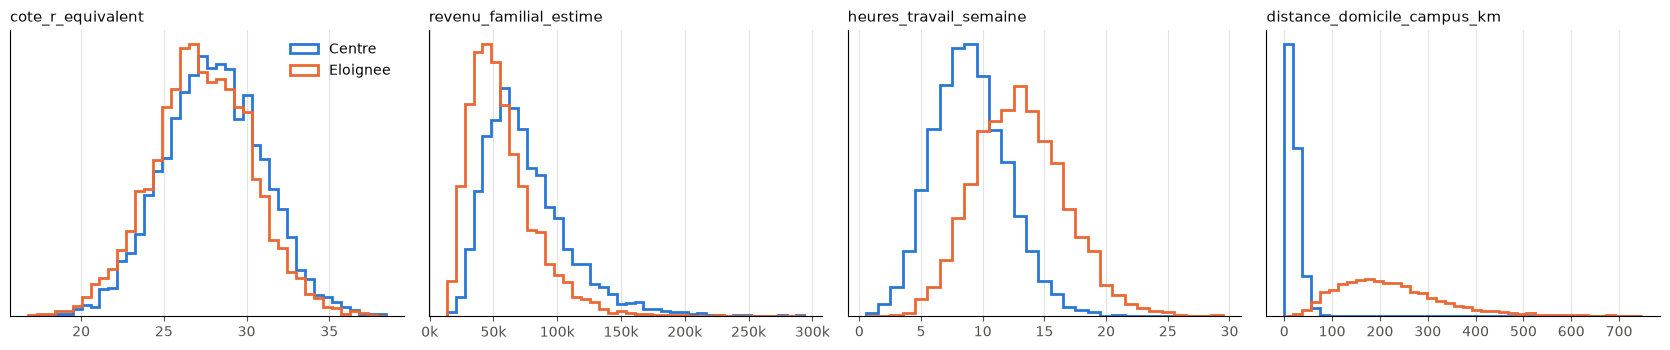

Support commun (part de chaque groupe dans l'etendue de l'autre) :
                             Centre dans etendue Eloignee  Eloignee dans etendue Centre
cote_r_equivalent                                   0.999                         1.000
revenu_familial_estime                              0.997                         0.995
heures_travail_semaine                              0.992                         0.998
distance_domicile_campus_km                         0.572                         0.208


In [10]:
print(stats_par_groupe(demandes, NUMERIQUES)[['moyenne', 'mediane', 'ecart_type', 'asymetrie']].round(2))
tracer_distributions(demandes, NUMERIQUES)
print('Support commun (part de chaque groupe dans l\'etendue de l\'autre) :')
print(pd.concat([chevauchement(demandes, c) for c in NUMERIQUES], axis=1).T.round(3))

**Lecture.**
- **Cote R** : presque la même distribution dans les deux groupes (27.3 contre 28.0, soit 0.2 écart-type) :
  ce n'est **pas** un proxy.
- **Distance** : presque disjointe (médiane de 205 km en région contre 17 km au Centre). Seuls 21 % des dossiers
  éloignés tombent dans l'étendue de distance du Centre : la distance **détermine presque** la région.
- **Heures travaillées** : environ 4 h de plus par semaine en région (13 contre 9) : proxy partiel.
- **Revenu** : environ 18 k$ de moins en région (médiane de 52 k$ contre 69 k$), avec une longue queue à droite
  dans les deux groupes : proxy partiel.
- Pour les heures et le revenu, les distributions se chevauchent largement (support commun de plus de 99 %) :
  ces variables portent une **partie** de l'information de région, mais aussi une information propre.

## B. Variables binaires et catégorielles

In [11]:
for col in ['premiere_generation_universitaire', 'programme_etudes']:
    print(repartition(demandes, col)['proportion'].drop(index='total').round(3), end='\n\n')

cp = demandes.groupby('code_postal_3')['groupe'].agg(['size', pd.Series.nunique])
print(f"code_postal_3 : {len(cp)} valeurs, de {cp['size'].min()} a {cp['size'].max()} dossiers chacune")
print('Codes postaux presents dans les deux groupes :', int((cp['nunique'] > 1).sum()))

groupe                             Centre  Eloignee
premiere_generation_universitaire                  
0                                   0.735     0.556
1                                   0.265     0.444

groupe             Centre  Eloignee
programme_etudes                   
Arts et lettres     0.152     0.202
Genie               0.253     0.194
Sante               0.172     0.188
Sciences            0.225     0.195
Sciences sociales   0.198     0.222

code_postal_3 : 18 valeurs, de 368 a 827 dossiers chacune
Codes postaux presents dans les deux groupes : 0


**Lecture.**
- **Code postal** : aucun des 18 codes n'est partagé entre les groupes. `code_postal_3` **détermine exactement**
  la région : c'est un proxy parfait.
- **Première génération** : 44 % en région contre 27 % au Centre : proxy faible.
- **Programme** : la répartition diffère d'au plus 6 points entre les groupes (Génie : 25 % contre 19 %) :
  ce n'est pas un proxy.

## C. Tableau des corrélations

Corrélations de Spearman (robustes aux queues longues du revenu et de la distance) entre les variables
numériques, l'indicateur de région `eloignee` (1 = région éloignée) et la décision du comité.

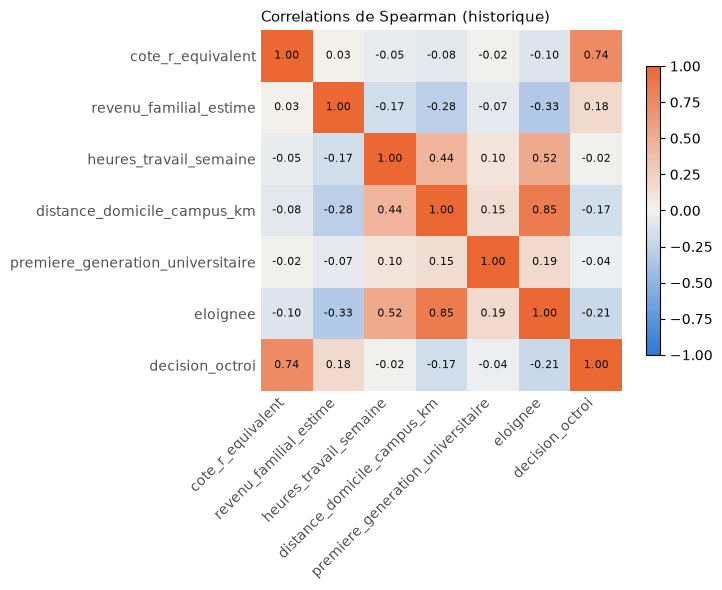

                                   eloignee  decision_octroi
cote_r_equivalent                    -0.104            0.736
revenu_familial_estime               -0.327            0.182
heures_travail_semaine                0.520           -0.016
distance_domicile_campus_km           0.845           -0.169
premiere_generation_universitaire     0.186           -0.038
eloignee                              1.000           -0.211
decision_octroi                      -0.211            1.000

Correlation de Spearman heures / decision, globale puis dans chaque groupe :
global     -0.016
Centre      0.116
Eloignee    0.105
dtype: float64


In [12]:
demandes['eloignee'] = (demandes['groupe'] == 'Eloignee').astype(int)
colonnes_corr = NUMERIQUES + ['premiere_generation_universitaire', 'eloignee', 'decision_octroi']
correlations = matrice_correlation(demandes, colonnes_corr)
tracer_matrice(correlations, 'Correlations de Spearman (historique)')
print(correlations[['eloignee', 'decision_octroi']].round(3))
print()
print('Correlation de Spearman heures / decision, globale puis dans chaque groupe :')
print(pd.Series({'global': demandes['heures_travail_semaine'].corr(demandes['decision_octroi'], method='spearman'),
                 **{g: s['heures_travail_semaine'].corr(s['decision_octroi'], method='spearman')
                    for g, s in demandes.groupby('groupe')}}).round(3))

**Lecture.**
- **Proxys de la région**, classés par corrélation avec `eloignee` : distance (**0.85**), heures travaillées
  (**0.52**), revenu (**-0.33**) et première génération (0.19). La cote R n'est presque pas corrélée à la région
  (-0.10). Le code postal, catégoriel, n'apparaît pas dans le tableau, mais c'est un proxy parfait (section B).
- **Décision du comité** : elle dépend surtout de la cote R (0.74), puis du revenu (0.18). Sa corrélation avec
  `eloignee` (-0.21) est celle de l'écart d'octroi de la section 0.
- **Paradoxe de Simpson sur les heures** : sur l'ensemble des données, les heures travaillées ne sont pas
  corrélées à la décision (-0.02). Pourtant, **dans chaque groupe**, elles l'augmentent (0.12 au Centre, 0.11 en
  région). Les candidats éloignés travaillent plus, mais obtiennent moins à cause de la pénalité régionale, ce
  qui masque l'effet global. Un audit limité aux corrélations globales conclurait à tort que les heures ne
  comptent pas.
- **Limite** : ces corrélations sont deux à deux. Une **combinaison** de proxys partiels (heures, revenu,
  première génération) peut retrouver la région mieux que chacun séparément.

| Variable | Lien avec la région | Statut |
|---|---|---|
| `code_postal_3` | détermine exactement la région | proxy parfait |
| `distance_domicile_campus_km` | presque disjointe entre groupes (corrélation 0.85) | proxy quasi parfait |
| `heures_travail_semaine` | +4 h en région (0.52) | proxy partiel, avec un effet propre sur la décision |
| `revenu_familial_estime` | -18 k$ en région (-0.33) | proxy partiel, avec un effet propre sur la décision |
| `premiere_generation_universitaire` | 44 % contre 27 % (0.19) | proxy faible |
| `cote_r_equivalent`, `programme_etudes` | distributions presque identiques | pas des proxys |